# 10. Full Baseline

## 1. 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
    BaggingRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

print('라이브러리 로드 완료')
print(f'Pandas 버전: {pd.__version__}')
print(f'Numpy 버전: {np.__version__}')

라이브러리 로드 완료
Pandas 버전: 2.3.3
Numpy 버전: 2.2.6


## 2. 데이터 로드

In [2]:
df = pd.read_csv('apt_ml_ready.csv', encoding='utf-8-sig')

print('데이터셋 기본 정보')
print(f'총 레코드 수: {len(df):,}건')
print(f'총 컬럼 수: {len(df.columns)}개')
print('\n컬럼 목록:')
print(df.columns.tolist())

데이터셋 기본 정보
총 레코드 수: 2,396,830건
총 컬럼 수: 18개

컬럼 목록:
['excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth', 'apt_age', 'nightlight_avg', 'nl_growth_trend', '고령화율', 'sgg_count', 'SGG_level', 'sgg_yearly_volume', 'aging_intensity_per_nl', 'cluster_name', 'dealAmount_num', 'log_dealAmount_num', 'KOSIS_SGG_CODE', 'SGG_NM_norm']


## 3. Full 피처 선택

In [3]:
# 9_baseline 대비 추가되는 스토리 변수
story_cols = [
    'nightlight_avg', 'nl_growth_trend', '고령화율',
    'aging_intensity_per_nl', 'cluster_name',
]

# 타깃·집계용 (피처 X)
non_feature = ['dealAmount_num', 'log_dealAmount_num', 'KOSIS_SGG_CODE', 'SGG_NM_norm']

feature_cols = [c for c in df.columns if c not in non_feature]
feature_num = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
feature_cat = [c for c in feature_cols if c not in feature_num]

baseline_n = len(df.columns) - len(story_cols) - len(non_feature)

print(f'Full 피처 {len(feature_cols)}개 (baseline {baseline_n} + 스토리 {len(story_cols)})')
print('수치형:', feature_num)
print('범주형:', feature_cat)
print('\n추가 (스토리):', story_cols)

Full 피처 14개 (baseline 9 + 스토리 5)
수치형: ['excluUseAr_num', 'floor_num', 'buildYear', 'dealYear', 'dealMonth', 'apt_age', 'nightlight_avg', 'nl_growth_trend', '고령화율', 'sgg_count', 'sgg_yearly_volume', 'aging_intensity_per_nl']
범주형: ['SGG_level', 'cluster_name']

추가 (스토리): ['nightlight_avg', 'nl_growth_trend', '고령화율', 'aging_intensity_per_nl', 'cluster_name']


## 4. train / test 분할

In [4]:
# 9_baseline과 동일 조건 — sample_n·random_state 맞춤
sample_n = 300_000
if len(df) > sample_n:
    df = df.sample(n=sample_n, random_state=42)
    print(f'샘플링: {sample_n:,}건')

X = df[feature_cols]
y_log = df['log_dealAmount_num']
y_won = df['dealAmount_num']

X_train, X_test, y_train, y_test, y_won_train, y_won_test = train_test_split(
    X, y_log, y_won, test_size=0.2, random_state=42
)

print(f'train: {len(X_train):,}건 / test: {len(X_test):,}건')

샘플링: 300,000건
train: 240,000건 / test: 60,000건


## 5. 모델 학습 · 비교

`log_dealAmount_num`으로 학습 → `expm1`로 만원 복원 후 MAE

In [5]:
def run_model(name, model, scale=False):
    prep_steps = []
    if feature_num:
        prep_steps.append(('num', StandardScaler() if scale else 'passthrough', feature_num))
    if feature_cat:
        prep_steps.append(('cat', OneHotEncoder(handle_unknown='ignore'), feature_cat))

    pipe = Pipeline([
        ('prep', ColumnTransformer(prep_steps)),
        ('model', model),
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    pred_log = pipe.predict(X_test)
    pred_won = np.expm1(pred_log)

    return {
        'model': name,
        'MAE_만원': mean_absolute_error(y_won_test, pred_won),
        'RMSE_만원': np.sqrt(mean_squared_error(y_won_test, pred_won)),
        'R2_log': r2_score(y_test, pred_log),
        'sec': round(time.time() - t0, 1),
    }

In [6]:
models = [
    ('LinearRegression', LinearRegression(), True),
    ('DecisionTree', DecisionTreeRegressor(max_depth=12, random_state=42), False),
    ('RandomForest', RandomForestRegressor(
        n_estimators=100, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=42), False),
    ('ExtraTrees', ExtraTreesRegressor(
        n_estimators=100, max_depth=14, min_samples_leaf=20,
        n_jobs=-1, random_state=42), False),
    ('GradientBoosting', GradientBoostingRegressor(
        n_estimators=100, max_depth=6, random_state=42), False),
    ('HistGradientBoosting', HistGradientBoostingRegressor(
        max_iter=100, max_depth=8, random_state=42), False),
    ('Bagging', BaggingRegressor(n_estimators=30, n_jobs=-1, random_state=42), False),
    (('XGBoost', XGBRegressor(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        n_jobs=-1, random_state=42, verbosity=0), False)),
    ('LightGBM', LGBMRegressor(
        n_estimators=100, max_depth=8, verbose=-1,
        n_jobs=-1, random_state=42), False),
]

print(f'총 {len(models)}개 모델')

총 9개 모델


In [7]:
results = []

for name, est, scale in models:
    print(f'학습 중: {name}...', end=' ')
    try:
        row = run_model(name, est, scale=scale)
        results.append(row)
        print(f"MAE {row['MAE_만원']:,.0f}만원 ({row['sec']}s)")
    except Exception as e:
        print(f'실패: {e}')

result_df = pd.DataFrame(results).sort_values('MAE_만원').reset_index(drop=True)

print('\n=== Full 모델 비교 (MAE 낮을수록 좋음) ===')
display(result_df.round({'MAE_만원': 0, 'RMSE_만원': 0, 'R2_log': 4}))

학습 중: LinearRegression... MAE 14,296만원 (0.1s)
학습 중: DecisionTree... MAE 7,679만원 (0.8s)
학습 중: RandomForest... MAE 6,498만원 (8.8s)
학습 중: ExtraTrees... MAE 7,439만원 (4.4s)
학습 중: GradientBoosting... MAE 7,053만원 (47.3s)
학습 중: HistGradientBoosting... MAE 7,295만원 (2.4s)
학습 중: Bagging... MAE 4,501만원 (7.9s)
학습 중: XGBoost... MAE 6,167만원 (0.6s)
학습 중: LightGBM... MAE 7,234만원 (0.7s)

=== Full 모델 비교 (MAE 낮을수록 좋음) ===


,model,MAE_만원,RMSE_만원,R2_log,sec
0,Bagging,4501.0,9624.0,0.9499,7.9
1,XGBoost,6167.0,11344.0,0.9147,0.6
2,RandomForest,6498.0,12733.0,0.9084,8.8
3,GradientBoosting,7053.0,13239.0,0.8935,47.3
4,LightGBM,7234.0,13922.0,0.8879,0.7
5,HistGradientBoosting,7295.0,14071.0,0.8864,2.4
6,ExtraTrees,7439.0,14340.0,0.8843,4.4
7,DecisionTree,7679.0,14753.0,0.8737,0.8
8,LinearRegression,14296.0,28073.0,0.6132,0.1


## 6. 시각화

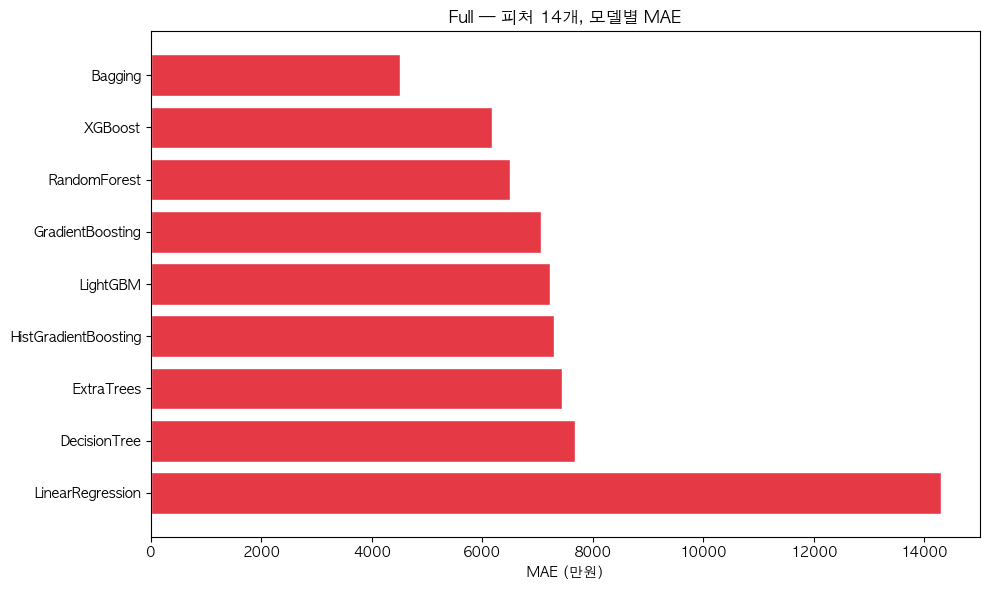

Full 1위: Bagging
MAE: 4,501 만원


In [8]:
plot_df = result_df.sort_values('MAE_만원', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df['model'], plot_df['MAE_만원'], color='#e63946', edgecolor='white')
plt.xlabel('MAE (만원)')
plt.title(f'Full — 피처 {len(feature_cols)}개, 모델별 MAE')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

best = result_df.iloc[0]
print(f"Full 1위: {best['model']}")
print(f"MAE: {best['MAE_만원']:,.0f} 만원")

## 7. 1위 모델 하이퍼파라미터 tuning

In [9]:
from sklearn.model_selection import RandomizedSearchCV

best_name = result_df.iloc[0]['model']
mae_before = result_df.iloc[0]['MAE_만원']

print('=== tuning 대상 ===')
print(f'모델: {best_name}')
print(f'튜닝 전 MAE: {mae_before:,.0f} 만원')

=== tuning 대상 ===
모델: Bagging
튜닝 전 MAE: 4,501 만원


In [10]:
tuning_table = {
    'HistGradientBoosting': (
        HistGradientBoostingRegressor(random_state=42), False,
        {
            'model__max_depth': [6, 8, 10, 12],
            'model__max_iter': [100, 200, 300],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__min_samples_leaf': [20, 50, 100],
        }
    ),
    'RandomForest': (
        RandomForestRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [10, 14, 18, None],
            'model__min_samples_leaf': [10, 20, 50],
            'model__max_features': ['sqrt', 0.5, 0.8],
        }
    ),
    'ExtraTrees': (
        ExtraTreesRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [100, 200, 300],
            'model__max_depth': [10, 14, 18, None],
            'model__min_samples_leaf': [10, 20, 50],
        }
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=42), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [4, 6, 8],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__min_samples_leaf': [20, 50],
        }
    ),
    'DecisionTree': (
        DecisionTreeRegressor(random_state=42), False,
        {
            'model__max_depth': [8, 12, 16, 20],
            'model__min_samples_leaf': [10, 20, 50, 100],
        }
    ),
    'LinearRegression': (
        LinearRegression(), True,
        {'model__fit_intercept': [True]},
    ),
    'Bagging': (
        BaggingRegressor(n_jobs=-1, random_state=42), False,
        {
            'model__n_estimators': [20, 30, 50],
            'model__max_samples': [0.7, 0.9, 1.0],
        }
    ),
}

try:
    from xgboost import XGBRegressor
    tuning_table['XGBoost'] = (
        XGBRegressor(n_jobs=-1, random_state=42, verbosity=0), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [6, 8, 10],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__subsample': [0.7, 0.9, 1.0],
        }
    )
except ImportError:
    pass

try:
    from lightgbm import LGBMRegressor
    tuning_table['LightGBM'] = (
        LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1), False,
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [6, 8, 10],
            'model__learning_rate': [0.05, 0.1, 0.15],
            'model__num_leaves': [31, 63, 127],
        }
    )
except ImportError:
    pass

if best_name not in tuning_table:
    raise ValueError(f'{best_name} — tuning_table에 그리드 추가 필요')

base_model, use_scale, param_grid = tuning_table[best_name]

prep_steps = []
if feature_num:
    prep_steps.append(('num', StandardScaler() if use_scale else 'passthrough', feature_num))
if feature_cat:
    prep_steps.append(('cat', OneHotEncoder(handle_unknown='ignore'), feature_cat))

tune_pipe = Pipeline([
    ('prep', ColumnTransformer(prep_steps)),
    ('model', base_model),
])

print(f'탐색 조합 수: {np.prod([len(v) for v in param_grid.values()]):,.0f} (RandomizedSearchCV n_iter=20)')

탐색 조합 수: 9 (RandomizedSearchCV n_iter=20)


In [24]:
search = RandomizedSearchCV(
    tune_pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print(f'=== {best_name} tuning 시작 ===')
t0 = time.time()
search.fit(X_train, y_train)
print(f'소요: {time.time() - t0:.0f}초')

print('\n최적 파라미터:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

=== Bagging tuning 시작 ===
Fitting 3 folds for each of 9 candidates, totalling 27 fits
소요: 213초

최적 파라미터:
  model__n_estimators: 50
  model__max_samples: 1.0


=== tuning 전후 성능 (test, 만원 MAE) ===


,구분,MAE_만원,RMSE_만원,R2_log,MAE_개선_만원
0,튜닝 전 (기본),4501.0,9624.0,0.9499,NaN
1,튜닝 후 (최적),4461.0,9572.0,0.9508,40.0


MAE 4,501 → 4,461 만원  (+0.89%)


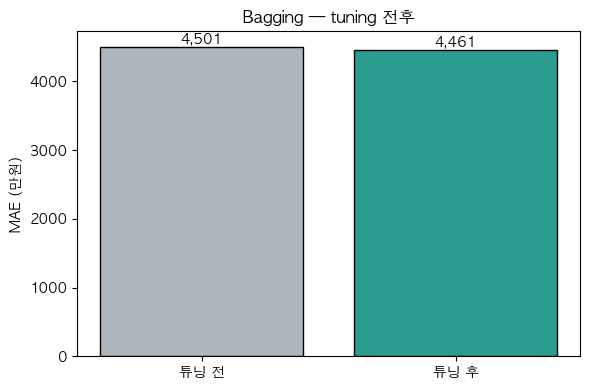

In [25]:
best_model = search.best_estimator_
pred_log = best_model.predict(X_test)
pred_won = np.expm1(pred_log)

mae_after = mean_absolute_error(y_won_test, pred_won)
rmse_after = np.sqrt(mean_squared_error(y_won_test, pred_won))
r2_after = r2_score(y_test, pred_log)

improve = mae_before - mae_after
pct = improve / mae_before * 100

compare = pd.DataFrame([
    {'구분': '튜닝 전 (기본)', 'MAE_만원': mae_before, 'RMSE_만원': result_df.iloc[0]['RMSE_만원'], 'R2_log': result_df.iloc[0]['R2_log']},
    {'구분': '튜닝 후 (최적)', 'MAE_만원': mae_after, 'RMSE_만원': rmse_after, 'R2_log': r2_after},
])
compare['MAE_개선_만원'] = [np.nan, improve]

print('=== tuning 전후 성능 (test, 만원 MAE) ===')
display(compare.round({'MAE_만원': 0, 'RMSE_만원': 0, 'R2_log': 4, 'MAE_개선_만원': 0}))
print(f'MAE {mae_before:,.0f} → {mae_after:,.0f} 만원  ({pct:+.2f}%)')

labels = ['튜닝 전', '튜닝 후']
maes = [mae_before, mae_after]
colors = ['#adb5bd', '#2a9d8f']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, maes, color=colors, edgecolor='black')
for bar, val in zip(bars, maes):
    plt.text(bar.get_x() + bar.get_width() / 2, val, f'{val:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylabel('MAE (만원)')
plt.title(f'{best_name} — tuning 전후')
plt.tight_layout()
plt.show()

## 8. 클러스터별 MAE - 최종 모델로 야간광 클러스터 마다 얼마나 차이나는지 확인하기

=== 클러스터별 MAE (튜닝 후 최적 모델) ===


,cluster_name,MAE_만원,건수
1,저광도,2728.0,31279
2,중광도,5574.0,21834
0,고광도,8802.0,6887


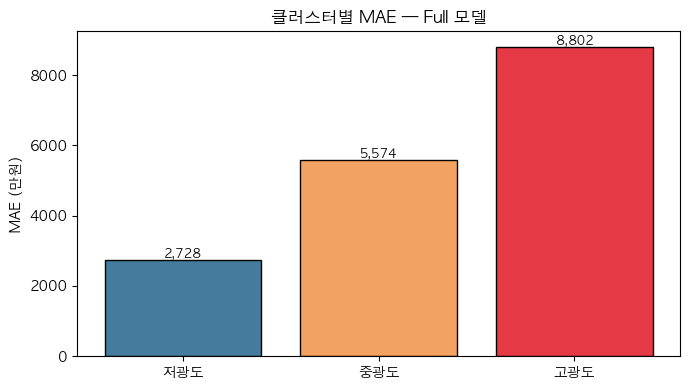

In [26]:
cluster_colors = {'고광도': '#e63946', '중광도': '#f4a261', '저광도': '#457b9d'}

test_cluster = df.loc[X_test.index, 'cluster_name']
err_df = pd.DataFrame({
    'cluster_name': test_cluster.values,
    'actual': y_won_test.values,
    'pred': pred_won,
    'abs_err': np.abs(y_won_test.values - pred_won),
})

cluster_mae = err_df.groupby('cluster_name').agg(
    MAE_만원=('abs_err', 'mean'),
    건수=('abs_err', 'count'),
).reset_index()
cluster_mae = cluster_mae.sort_values('MAE_만원')

print('=== 클러스터별 MAE (튜닝 후 최적 모델) ===')
display(cluster_mae.round({'MAE_만원': 0}))

plt.figure(figsize=(7, 4))
bar_colors = [cluster_colors.get(c, 'gray') for c in cluster_mae['cluster_name']]
plt.bar(cluster_mae['cluster_name'], cluster_mae['MAE_만원'], color=bar_colors, edgecolor='black')
plt.ylabel('MAE (만원)')
plt.title('클러스터별 MAE — Full 모델')
for i, row in cluster_mae.iterrows():
    plt.text(row['cluster_name'], row['MAE_만원'], f"{row['MAE_만원']:,.0f}",
             ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 풀 데이터셋 재학습 (튜닝 Bagging)

튜닝 완료된 모델로 전체 239만건을 다시 학습하고, 4가지 지표 + 클러스터별 시각화를 확인.

풀 데이터: 2,396,830건 (샘플링 없음)
train: 1,917,464 / test: 479,366
학습 소요: 540초
사용 파라미터: {'model__n_estimators': 50, 'model__max_samples': 1.0}

=== 풀 데이터 test — 4지표 ===


,MAE_만원,RMSE_만원,R2_log,MAPE_pct
0,2560.0,6060.0,0.9794,7.7



=== 클러스터별 4지표 (풀 데이터) ===


,cluster_name,MAE_만원,RMSE_만원,R2_log,MAPE_pct,건수
1,저광도,1558.0,2936.0,0.9753,7.6,250923.0
2,중광도,3184.0,6698.0,0.9735,7.7,173627.0
0,고광도,5170.0,11814.0,0.9765,8.3,54816.0


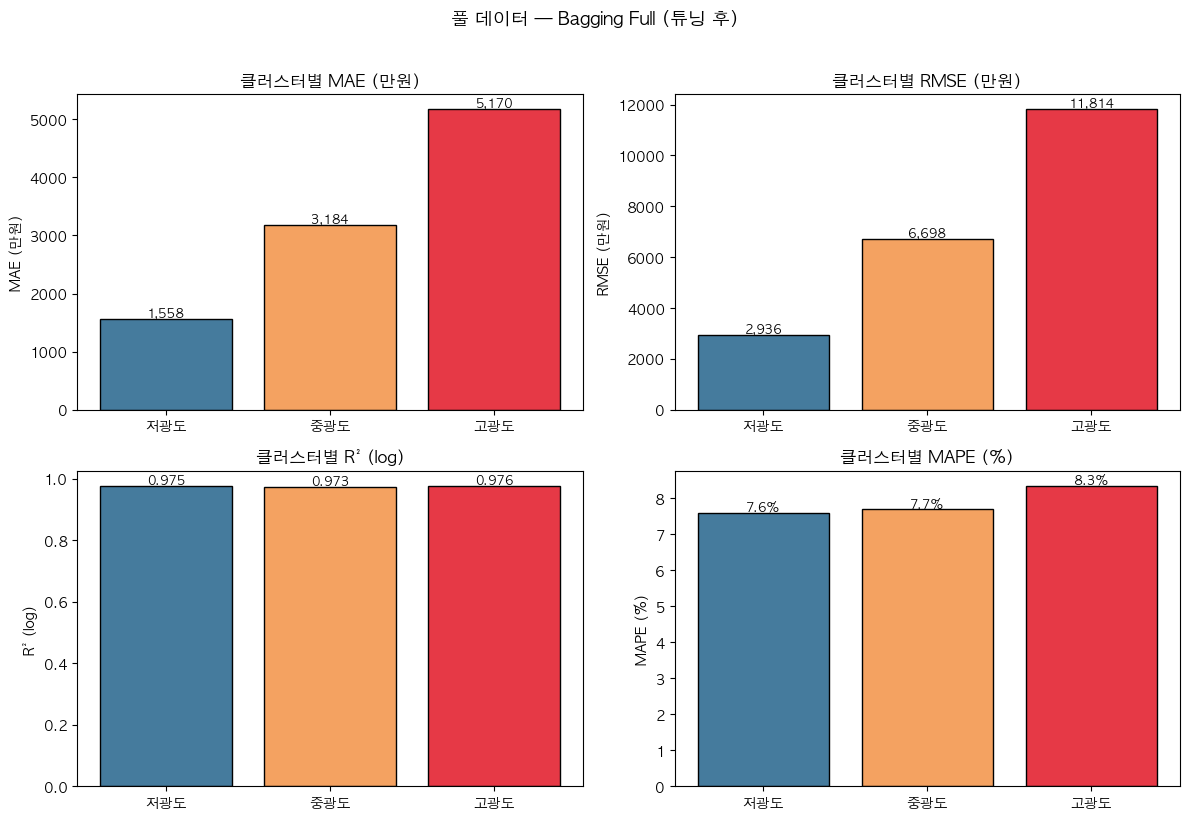

In [27]:
from sklearn.base import clone

df_full = pd.read_csv('apt_ml_ready.csv', encoding='utf-8-sig')
print(f'풀 데이터: {len(df_full):,}건 (샘플링 없음)')

X_all = df_full[feature_cols]
y_log_all = df_full['log_dealAmount_num']
y_won_all = df_full['dealAmount_num']

X_tr, X_te, y_tr, y_te, y_won_tr, y_won_te = train_test_split(
    X_all, y_log_all, y_won_all, test_size=0.2, random_state=42,
)
print(f'train: {len(X_tr):,} / test: {len(X_te):,}')

t0 = time.time()
full_model = clone(search.best_estimator_)
full_model.fit(X_tr, y_tr)
print(f'학습 소요: {time.time() - t0:.0f}초')
print('사용 파라미터:', search.best_params_)

pred_log = full_model.predict(X_te)
pred_won = np.expm1(pred_log)

actual = y_won_te.values
mae_full = mean_absolute_error(actual, pred_won)
rmse_full = np.sqrt(mean_squared_error(actual, pred_won))
r2_full = r2_score(y_te, pred_log)
mape_full = (np.abs(actual - pred_won) / np.clip(actual, 1, None)).mean() * 100

overall = pd.DataFrame([{
    'MAE_만원': mae_full, 'RMSE_만원': rmse_full,
    'R2_log': r2_full, 'MAPE_pct': mape_full,
}])
print('\n=== 풀 데이터 test — 4지표 ===')
display(overall.round({'MAE_만원': 0, 'RMSE_만원': 0, 'R2_log': 4, 'MAPE_pct': 1}))

err_df = pd.DataFrame({
    'cluster_name': df_full.loc[X_te.index, 'cluster_name'].values,
    'actual': actual,
    'pred': pred_won,
    'pred_log': pred_log,
    'y_log': y_te.values,
})
err_df['abs_err'] = np.abs(err_df['actual'] - err_df['pred'])
err_df['sq_err'] = (err_df['actual'] - err_df['pred']) ** 2
err_df['ape'] = err_df['abs_err'] / np.clip(err_df['actual'], 1, None) * 100

def _cluster_metrics(g):
    return pd.Series({
        'MAE_만원': g['abs_err'].mean(),
        'RMSE_만원': np.sqrt(g['sq_err'].mean()),
        'R2_log': r2_score(g['y_log'], g['pred_log']),
        'MAPE_pct': g['ape'].mean(),
        '건수': len(g),
    })

cluster_stats = err_df.groupby('cluster_name').apply(_cluster_metrics, include_groups=False).reset_index()
cluster_stats = cluster_stats.sort_values('MAE_만원')

print('\n=== 클러스터별 4지표 (풀 데이터) ===')
display(cluster_stats.round({'MAE_만원': 0, 'RMSE_만원': 0, 'R2_log': 4, 'MAPE_pct': 1}))

cluster_colors = {'고광도': '#e63946', '중광도': '#f4a261', '저광도': '#457b9d'}
colors = [cluster_colors.get(c, 'gray') for c in cluster_stats['cluster_name']]
metrics = [
    ('MAE_만원', 'MAE (만원)', '{:,.0f}'),
    ('RMSE_만원', 'RMSE (만원)', '{:,.0f}'),
    ('R2_log', 'R² (log)', '{:.3f}'),
    ('MAPE_pct', 'MAPE (%)', '{:.1f}%'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (col, ylabel, fmt) in zip(axes.ravel(), metrics):
    vals = cluster_stats[col]
    ax.bar(cluster_stats['cluster_name'], vals, color=colors, edgecolor='black')
    ax.set_ylabel(ylabel)
    ax.set_title(f'클러스터별 {ylabel}')
    for _, row in cluster_stats.iterrows():
        ax.text(row['cluster_name'], row[col], fmt.format(row[col]),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.suptitle(f'풀 데이터 — {best_name} Full (튜닝 후)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()